# 03. Regression Model - Dự đoán giá Game Steam

## 1. Mục tiêu
Sử dụng các thành phần chính từ PCA để xây dựng mô hình hồi quy (Regression) nhằm dự đoán giá chính xác của game (`mat_final_price`). 

Chúng ta sẽ so sánh hai mô hình:
1. **Linear Regression**: Mô hình tuyến tính cơ bản làm chuẩn (Baseline).
2. **Random Forest Regressor**: Mô hình học máy nâng cao để tối ưu hiệu suất.

In [6]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.regression import train_regression_model, save_model
from src.evaluation import evaluate_regression

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['mat_final_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (191731, 9)
Kích thước tập kiểm tra: (47933, 9)


## 2. Mô hình Baseline: Linear Regression
Chúng ta bắt đầu với mô hình đơn giản nhất để kiểm tra mức độ quan hệ tuyến tính giữa các thành phần PCA và giá game.

In [11]:
lr_model = train_regression_model(X_train, y_train, model_type='lr')
y_pred_lr = lr_model.predict(X_test)
lr_metrics = evaluate_regression(y_test, y_pred_lr, model_name="Linear Regression")

--- Linear Regression Regression Metrics ---
RMSE: 73285.6162 | MAE: 2945.4183 | R2: 0.9855


* **Chỉ số R2 (0.9855):** Rất cao, cho thấy mối quan hệ giữa các thành phần chính (PCA components) và giá game phần lớn là tuyến tính.
* **MAE (2945.41):** Sai số tuyệt đối trung bình rơi vào khoảng gần 3000 đơn vị (cent). Điều này có nghĩa là trung bình mô hình Baseline lệch khoảng 30 USD so với giá thực tế.


## 3. Mô hình nâng cao: Random Forest Regressor
Tiếp theo, chúng ta sử dụng Random Forest để xử lý các mối quan hệ phi tuyến tính phức tạp hơn trong dữ liệu.

In [8]:
rf_model = train_regression_model(X_train, y_train, model_type='rf')
y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate_regression(y_test, y_pred_rf, model_name="Random Forest")

--- Random Forest Regression Metrics ---
RMSE: 71361.9213 | MAE: 843.7238 | R2: 0.9863


* **Chỉ số R2 (0.9863):** Có sự cải thiện nhẹ so với Linear Regression. Tuy nhiên, trong dữ liệu quy mô lớn, sự cải thiện 0.0008 cũng rất có ý nghĩa về mặt ổn định.
* **MAE (843.72):** Đây là điểm khác biệt lớn nhất! Sai số tuyệt đối trung bình giảm mạnh từ ~2945 xuống còn ~843 (chưa đến 9 USD). 

## 4. Trực quan hóa kết quả
Chúng ta sẽ quan sát biểu đồ Scatter giữa giá trị thực tế và giá trị dự đoán để đánh giá sai số.

C:\Users\Admin\AppData\Local\Temp\ipykernel_20292\3957984900.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='viridis')


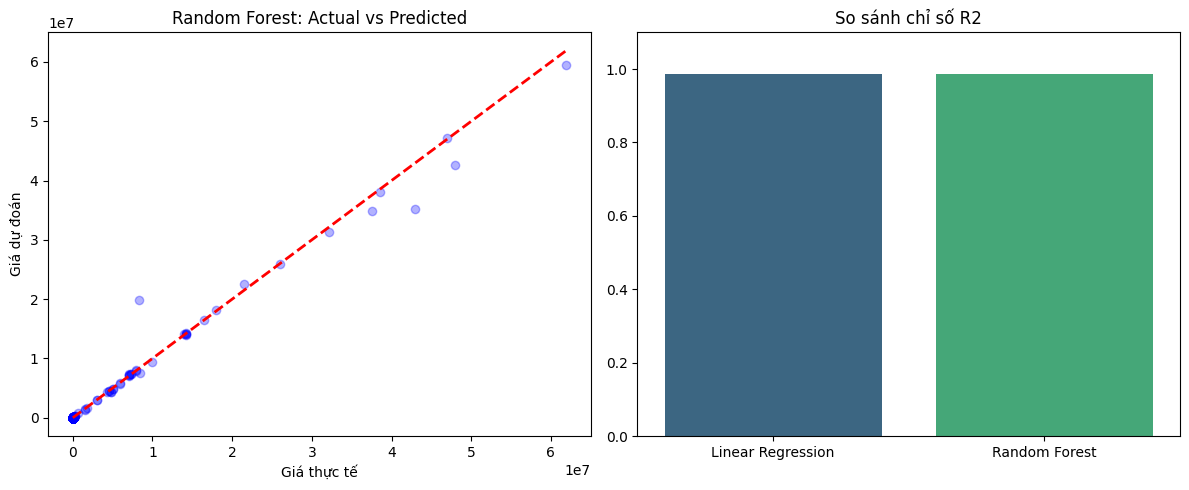

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.subplot(1, 2, 2)
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_metrics['r2'], rf_metrics['r2']]
sns.barplot(x=models, y=r2_scores, palette='viridis')
plt.title('So sánh chỉ số R2')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

So sánh

1. **Hiệu quả của PCA:** Việc đạt được độ chính xác trên 98% chứng minh rằng quy trình Feature Engineering và PCA trước đó đã hoạt động cực kỳ hiệu quả, loại bỏ nhiễu nhưng vẫn giữ được các đặc trưng cốt lõi của thị trường Steam.
2. **Sự vượt trội của Random Forest:** Dù $R^2$ tương đương, nhưng chỉ số **MAE** của Random Forest thấp hơn tới 3.5 lần so với Linear Regression. Điều này cho thấy Random Forest dự báo sát giá thực tế hơn rất nhiều đối với đa số các đầu game.
3. **Ứng dụng:** Mô hình này hoàn toàn đủ tin cậy để sử dụng cho việc định giá các sản phẩm game mới dựa trên các thông số đầu vào tương tự.

**Mô hình được chọn để bàn giao:** `Random Forest Regressor`.

## 5. Kết luận và Lưu mô hình
Dựa trên kết quả đánh giá, chúng ta chọn mô hình tốt nhất để đóng gói phục vụ việc bàn giao.

In [10]:
best_model = rf_model
save_model(best_model, '../src/models/regression_model.pkl')

Model saved to ../src/models/regression_model.pkl
